In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../processed_data/cmi_preprocessed.csv", index_col='id')
print(df.head())

    Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  Physical-Height  \
id                                                                       
0               5.0                0             51.0       116.840000   
1               9.0                0             60.5       121.920000   
2              10.0                1             71.0       143.510000   
3               9.0                0             71.0       142.240000   
4              18.0                1             65.0       137.862733   

    Physical-Weight  Physical-HeartRate  BIA-BIA_Activity_Level_num  \
id                                                                    
0         23.042474           84.333333                         2.0   
1         20.865232           70.000000                         2.0   
2         34.291555           94.000000                         3.0   
3         37.013107           97.000000                         3.0   
4         34.926584           89.000000                

In [ ]:
cols_to_keep = ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-Height", "Physical-HeartRate", "BIA-BIA_BMI",
"BIA-BIA_DEE", "BIA-BIA_FFMI", "BIA-BIA_FMI", "Physical-Mean_arterial_pressure", "PAQ_Combined"]
df_outlier_detection = df[cols_to_keep]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_outlier_detection)

In [5]:
from pyod.models.abod import ABOD
clf = ABOD(contamination=0.01)
clf.fit(X)

,contamination,0.01
,n_neighbors,5
,method,'fast'
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1


In [6]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8176,   83]))

In [ ]:
# Score distribution — ABOD scores are heavy-tailed (a few points sit at ~-1e8),
# so use a symlog x-axis and log y to keep the threshold region readable.
scores = clf.decision_scores_
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores, bins=120, edgecolor="white", alpha=0.7)
ax.axvline(clf.threshold_, color="red", linestyle="--",
           label=f"99th percentile = {clf.threshold_:.2e}")
ax.set_xscale("symlog", linthresh=1e-3)
ax.set_yscale("log")
ax.set_xlabel("Anomaly Score (symlog)")
ax.set_ylabel("Frequency (log)")
ax.set_title("ABOD — Anomaly Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
df_outlier_detection['anomaly_score'] = clf.decision_scores_
df_outlier_detection['is_outlier'] = clf.labels_

outliers = df_outlier_detection[df_outlier_detection['is_outlier'] == 1]
print(f"outliers: {len(outliers)} / {len(df_outlier_detection)}")

df_outlier_detection.sort_values(by='anomaly_score', ascending=False).head(10)

outliers: 83 / 8259


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,...,BIA-BIA_FMI,BIA-BIA_Frame_num,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined,anomaly_score,is_outlier
id,,,,,,,,,,,,,,,,,,,,,
6273,16.0,0,49.0,177.342800,68.447033,87.5,3.0,20.548077,124728.000000,116.891346,...,16.920504,2.0,2.0,0.0,119.666667,30.044888,5,2.666667,-1.475697e-07,1
5448,10.0,0,71.5,152.323800,52.027002,68.0,2.0,18.078301,124728.000000,86.229052,...,4.886692,2.0,1.0,0.0,76.166667,17.559884,2,2.000000,-4.525722e-07,1
5615,13.0,1,55.5,166.954200,49.849761,70.5,4.0,21.561823,80961.750842,489.246499,...,4.830934,2.0,0.0,0.0,80.666667,14.640468,6,2.500000,-6.877982e-07,1
6552,17.0,1,63.0,169.384133,25.764026,73.5,4.0,20.510781,2437.143008,91.834628,...,2.531601,3.0,0.0,2.0,87.666667,10.164269,7,3.000000,-9.108378e-07,1
4435,15.0,0,64.5,175.539400,58.286572,73.5,3.0,26.513136,2180.696351,8799.080000,...,2.636257,3.0,2.0,2.0,92.833333,45.898874,2,3.000000,-1.224276e-06,1
4113,7.0,0,57.0,146.939000,27.351598,96.5,3.0,15.619938,1713.077000,3529.994813,...,2.589841,1.0,2.0,2.0,102.166667,3.884052,6,2.500000,-1.234931e-06,1
4028,7.0,0,61.0,170.383200,91.308070,62.5,3.0,24.471299,3184.440913,152.350596,...,5.897493,2.0,3.0,2.0,87.166667,5.251441,2,1.503333,-1.917667e-06,1
7416,19.0,1,50.5,165.074600,31.025693,98.0,2.0,43.314244,1624.179179,68.760009,...,8.888031,1.0,3.0,0.0,97.777778,12.440813,3,2.500000,-2.717046e-06,1
3473,6.0,1,65.0,105.410000,16.782904,106.0,3.0,48.375400,1607.800000,49.295300,...,28.251500,1.0,0.0,0.0,88.000000,11.614558,6,2.185000,-2.792853e-06,1


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 23.39%, PC2: 6.62%
Cumulative (2 PCs): 30.01%


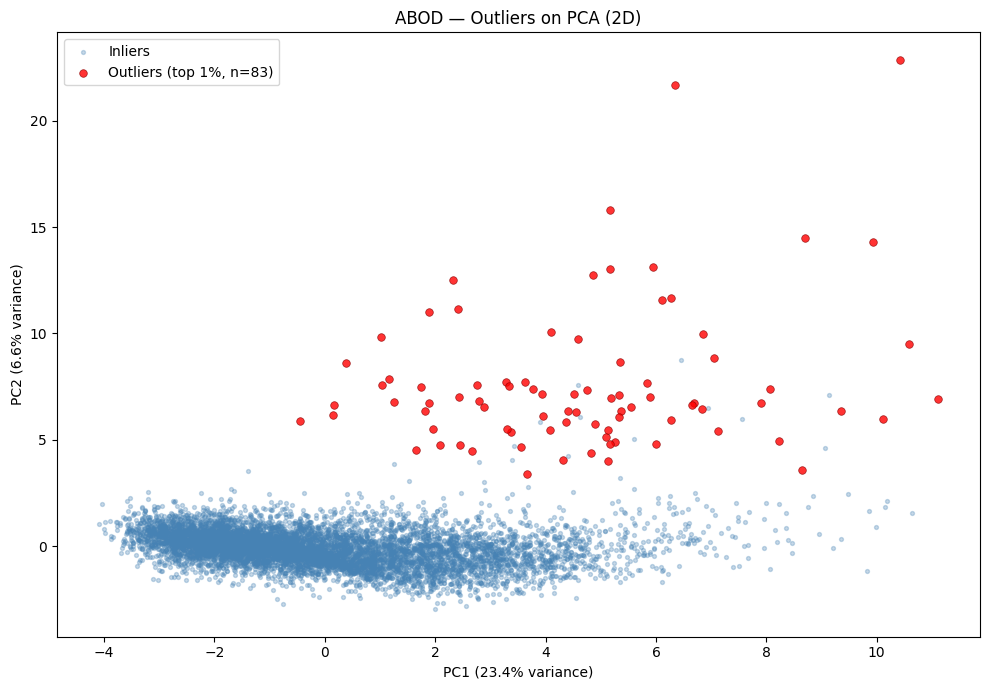

In [9]:
outlier_mask = clf.labels_ == 1
n_outliers = outlier_mask.sum()

fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("ABOD — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
df_outlier_detection.to_csv('../../outlier_data/abod.csv')